Dataset shape: (30, 6)
===== Basic Information =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Company    30 non-null     object
 1   Industry   30 non-null     object
 2   Revenue_m  30 non-null     int64 
 3   Profit_m   30 non-null     int64 
 4   Country    30 non-null     object
 5   Rank       30 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 1.5+ KB
None

===== Numerical Statistics =====
           Revenue_m       Profit_m       Rank
count      30.000000      30.000000  30.000000
mean   232563.266667   26770.833333  15.500000
std    118397.975646   26851.571531   8.803408
min    124314.000000    2761.000000   1.000000
25%    151850.000000   10661.000000   8.250000
50%    194979.000000   12619.000000  15.500000
75%    264087.500000   34205.750000  22.750000
max    611289.000000  105369.000000  30.000000
Filtered records: 30


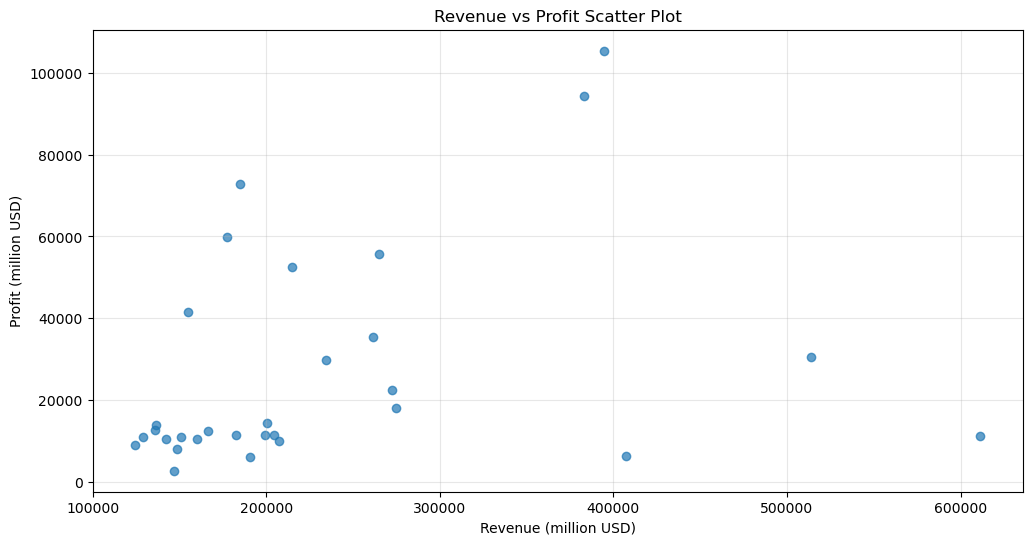

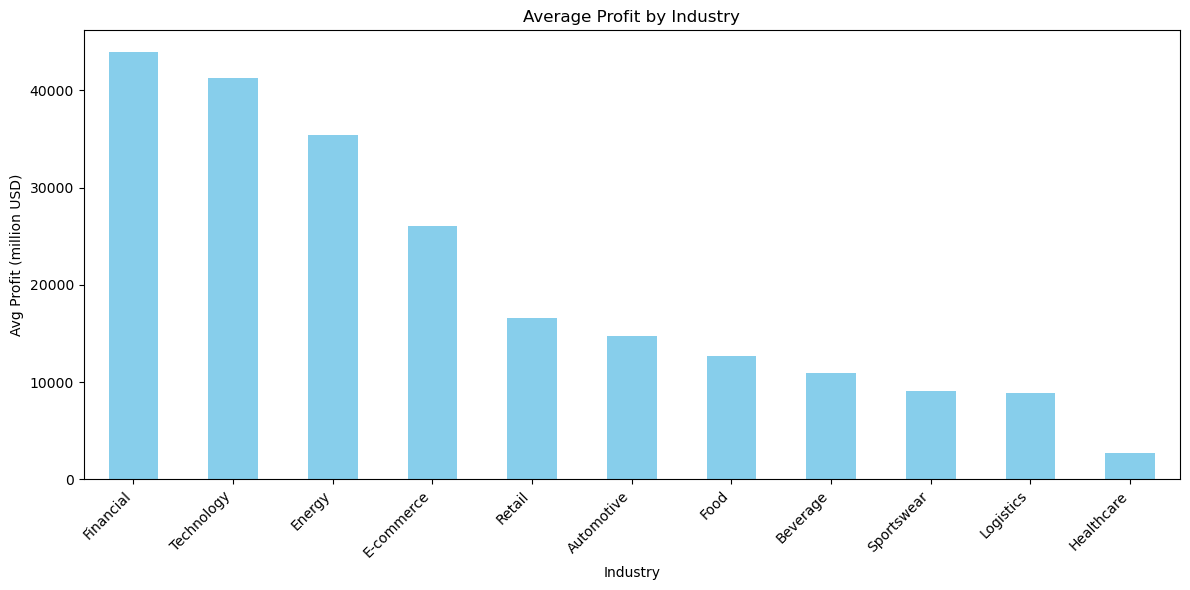

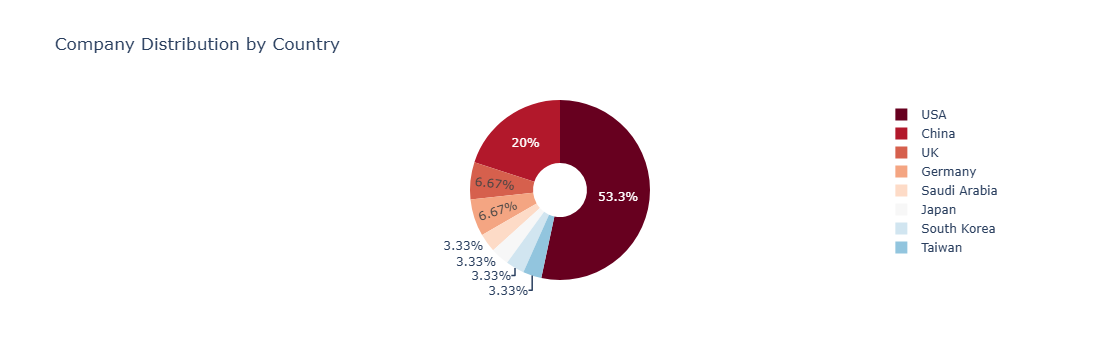

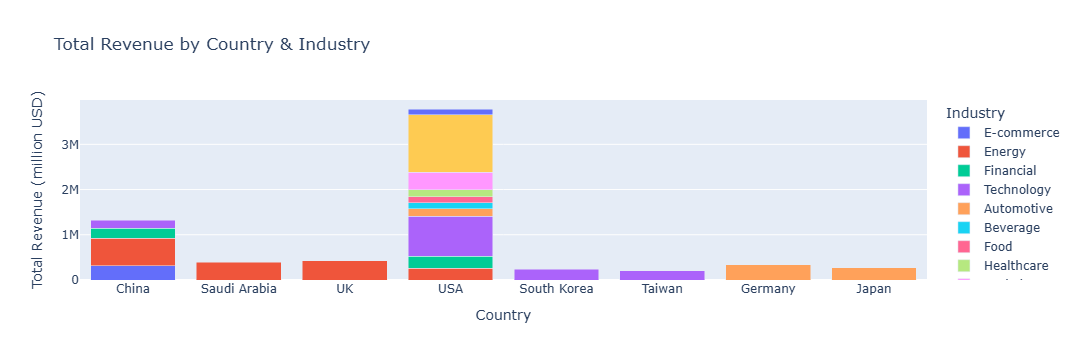

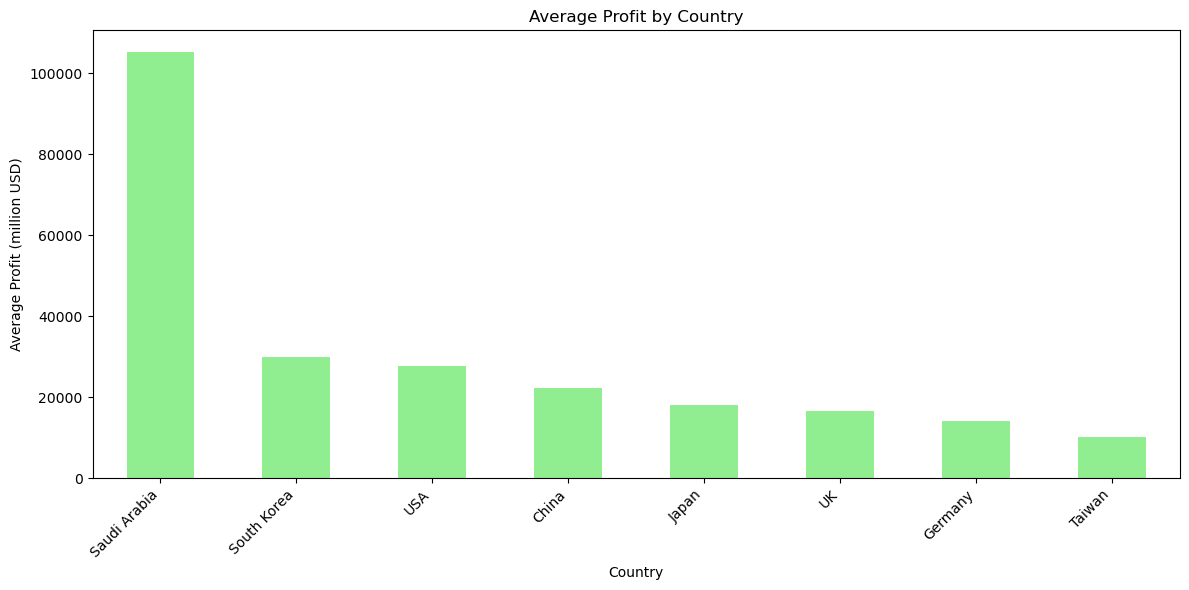

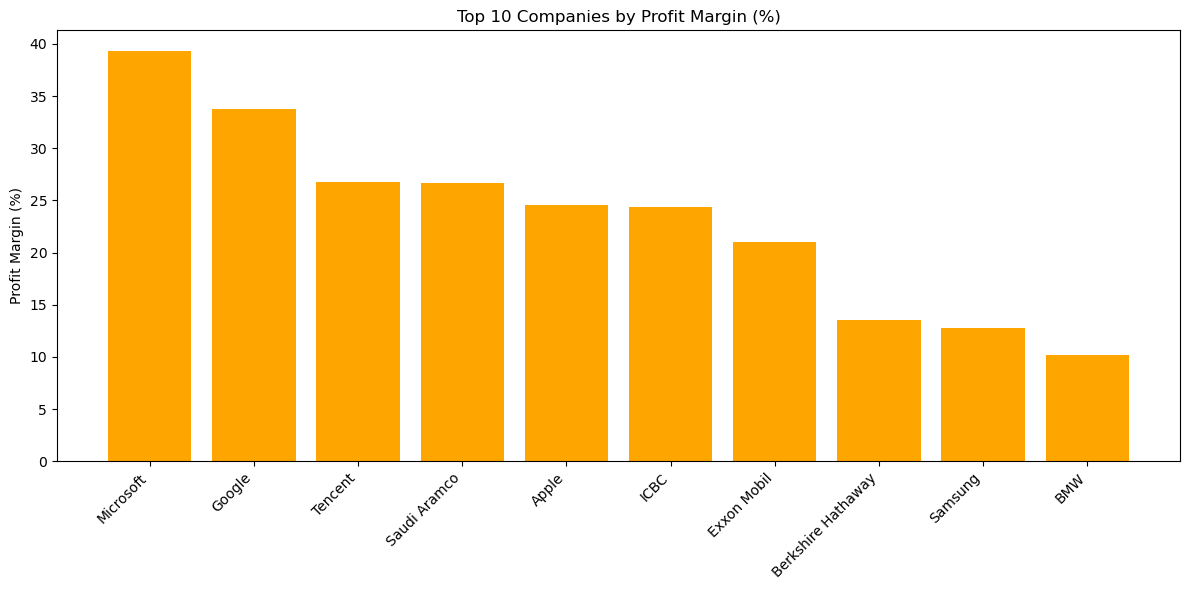

Current Industry: Retail


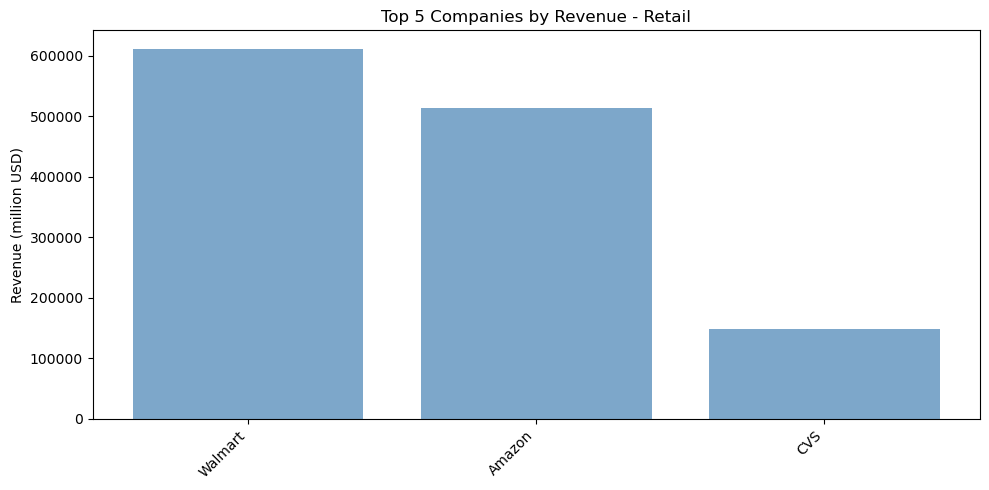

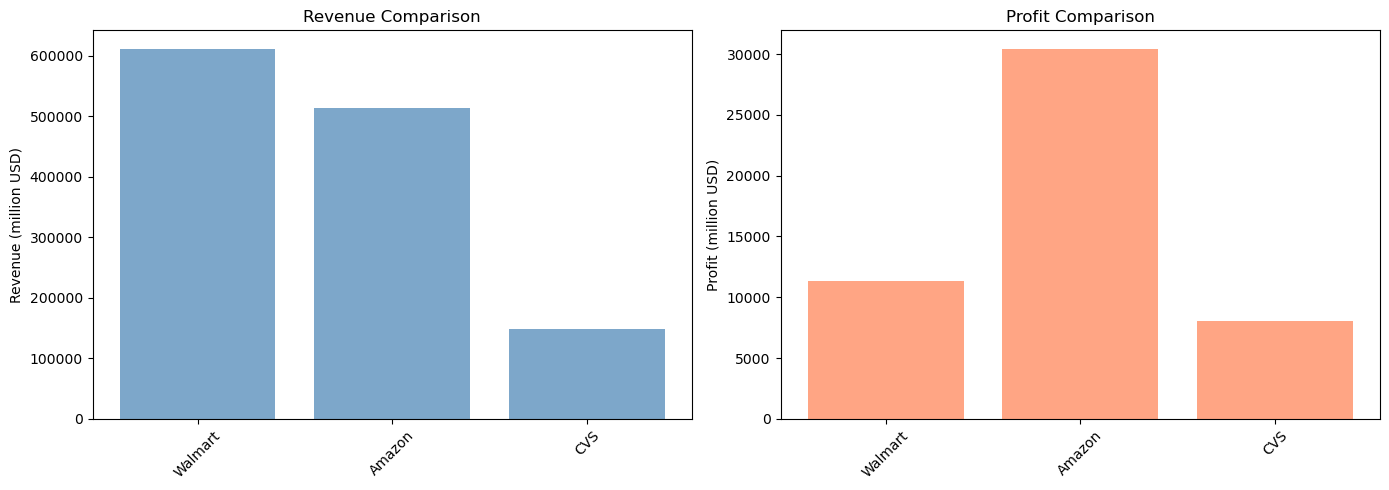

===== Overall Data Summary =====
Profit Margin Range: 1.5% ~ 39.3%
Average Profit Margin: 11.7%
Top Country by Avg Profit: Saudi Arabia ($105369.0M)
Industry with Most Companies: Technology
Companies after advanced filter: 30
===== Filtered Results Summary =====
Average Revenue: 232563.3 million USD
Average Profit: 26770.8 million USD
Average Profit Margin: 11.7%


In [1]:
# %% [markdown]
# # Fortune 500 Data Analysis
# ## Global Top 500 Companies Dashboard

# %%
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

plt.rcParams["axes.unicode_minus"] = False

# %% [markdown]
# ## 1. Load Dataset
df = pd.read_csv("fortune_500_small.csv")
print("Dataset shape:", df.shape)

df

# %% [markdown]
# ## 2. Basic Data Information
print("===== Basic Information =====")
print(df.info())
print("\n===== Numerical Statistics =====")
print(df.describe())

# %% [markdown]
# ## 3. Filter Data by Industry & Country
selected_industry = df["Industry"].unique().tolist()
selected_country = df["Country"].unique().tolist()

df_filtered = df[(df["Industry"].isin(selected_industry)) & 
                 (df["Country"].isin(selected_country))]

print("Filtered records:", len(df_filtered))
df_filtered.head()

# %% [markdown]
# ## 4. Key Financial Statistics
total_companies = len(df_filtered)
avg_revenue = round(df_filtered["Revenue_m"].mean(), 2)
avg_profit = round(df_filtered["Profit_m"].mean(), 2)

print("===== Key Statistics =====")
print(f"Total Companies: {total_companies}")
print(f"Avg Revenue (million USD): {avg_revenue}")
print(f"Avg Profit (million USD): {avg_profit}")

# %% [markdown]
# ## 5. Revenue vs Profit Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(df_filtered["Revenue_m"], df_filtered["Profit_m"], alpha=0.7, color="#1f77b4")
plt.xlabel("Revenue (million USD)")
plt.ylabel("Profit (million USD)")
plt.title("Revenue vs Profit Scatter Plot")
plt.grid(alpha=0.3)
plt.show()

# %% [markdown]
# ## 6. Average Profit by Industry
industry_profit = df_filtered.groupby("Industry")["Profit_m"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
industry_profit.plot(kind="bar", color="skyblue")
plt.ylabel("Avg Profit (million USD)")
plt.title("Average Profit by Industry")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Company Distribution by Country (Pie Chart)
country_counts = df_filtered['Country'].value_counts()
fig = px.pie(
    values=country_counts.values,
    names=country_counts.index,
    title="Company Distribution by Country",
    hole=0.3,
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig.show()

# %% [markdown]
# ## 8. Total Revenue by Country & Industry
country_industry = df_filtered.groupby(['Country', 'Industry'])['Revenue_m'].sum().reset_index()
fig = px.bar(
    country_industry,
    x='Country',
    y='Revenue_m',
    color='Industry',
    title="Total Revenue by Country & Industry",
    labels={'Revenue_m': 'Total Revenue (million USD)', 'Country': 'Country'},
    barmode='stack'
)
fig.show()

# %% [markdown]
# ## 9. Country Statistics
country_stats = df.groupby("Country").agg(
    Number_of_Companies=("Company", "count"),
    Average_Profit=("Profit_m", "mean")
).sort_values(by="Average_Profit", ascending=False)

country_stats

# %% [markdown]
# ## 10. Average Profit by Country
plt.figure(figsize=(12, 6))
country_stats["Average_Profit"].plot(kind="bar", color="lightgreen")
plt.title("Average Profit by Country")
plt.ylabel("Average Profit (million USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 11. Profit Margin Analysis
df["Profit_Margin"] = df["Profit_m"] / df["Revenue_m"] * 100
top_margin = df[["Company", "Profit_Margin"]].sort_values(by="Profit_Margin", ascending=False).head(10)

top_margin

# %% [markdown]
# ## 12. Top 10 Companies by Profit Margin
plt.figure(figsize=(12, 6))
plt.bar(top_margin["Company"], top_margin["Profit_Margin"], color='orange')
plt.title("Top 10 Companies by Profit Margin (%)")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 13. Top 5 Companies by Industry
selected_ind = df["Industry"].unique()[0]
print(f"Current Industry: {selected_ind}")

industry_data = df[df["Industry"] == selected_ind]
top5_companies = industry_data.nlargest(5, "Revenue_m")[["Company", "Revenue_m", "Profit_m"]]

top5_companies

# %% [markdown]
# ## 14. Top 5 Revenue in Selected Industry
plt.figure(figsize=(10, 5))
plt.bar(top5_companies["Company"], top5_companies["Revenue_m"], color='steelblue', alpha=0.7)
plt.title(f"Top 5 Companies by Revenue - {selected_ind}")
plt.ylabel("Revenue (million USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 15. Revenue vs Profit Comparison (Dual Chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(top5_companies["Company"], top5_companies["Revenue_m"], color='steelblue', alpha=0.7)
ax1.set_title("Revenue Comparison")
ax1.set_ylabel("Revenue (million USD)")
ax1.tick_params(axis='x', rotation=45)

ax2.bar(top5_companies["Company"], top5_companies["Profit_m"], color='coral', alpha=0.7)
ax2.set_title("Profit Comparison")
ax2.set_ylabel("Profit (million USD)")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 16. Overall Data Summary
margin_min = round(df['Profit_Margin'].min(), 1)
margin_max = round(df['Profit_Margin'].max(), 1)
avg_margin = round(df['Profit_Margin'].mean(), 1)
top_country = country_stats.index[0]
top_country_profit = round(country_stats.iloc[0]["Average_Profit"], 1)
top_industry = df['Industry'].value_counts().index[0]

print("===== Overall Data Summary =====")
print(f"Profit Margin Range: {margin_min}% ~ {margin_max}%")
print(f"Average Profit Margin: {avg_margin}%")
print(f"Top Country by Avg Profit: {top_country} (${top_country_profit}M)")
print(f"Industry with Most Companies: {top_industry}")

# %% [markdown]
# ## 17. Advanced Filtering
margin_low = 0
margin_high = df['Profit_Margin'].max()
revenue_low = df['Revenue_m'].min()
revenue_high = df['Revenue_m'].max()

advanced_filtered = df[
    (df['Profit_Margin'] >= margin_low) & 
    (df['Profit_Margin'] <= margin_high) &
    (df['Revenue_m'] >= revenue_low) & 
    (df['Revenue_m'] <= revenue_high)
]

print(f"Companies after advanced filter: {len(advanced_filtered)}")
advanced_filtered.head(10)

# %% [markdown]
# ## 18. Filtered Results Summary
if len(advanced_filtered) > 0:
    filt_avg_rev = round(advanced_filtered['Revenue_m'].mean(), 1)
    filt_avg_pro = round(advanced_filtered['Profit_m'].mean(), 1)
    filt_avg_mar = round(advanced_filtered['Profit_Margin'].mean(), 1)

    print("===== Filtered Results Summary =====")
    print(f"Average Revenue: {filt_avg_rev} million USD")
    print(f"Average Profit: {filt_avg_pro} million USD")
    print(f"Average Profit Margin: {filt_avg_mar}%")